# HW9

В этом ноутбуке:
- запускаем подготовку артефактов для ядра скоринга
- загружаем признаки, модель и результаты скоринга
- проверяем, что вероятности из ядра совпадают с прямым `predict_proba()`
- смотрим на итоговую policy и бизнес-экономику

In [1]:
from pathlib import Path
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

PROJECT_ROOT

WindowsPath('C:/Users/denis/credit_scoring')

## Подготовка артефактов

Эта ячейка запускает скрипт, который:
- копирует `gradient_boosting.pkl` в папку артефактов
- собирает итоговый DataFrame признаков
- выделяет validation-выборку
- считает вероятности и сохраняет сводные таблицы

In [2]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "hw6_core"
required_artifacts = [
    ARTIFACTS_DIR / "gradient_boosting.pkl",
    ARTIFACTS_DIR / "application_scoring_features.parquet",
    ARTIFACTS_DIR / "validation_features.parquet",
    ARTIFACTS_DIR / "validation_scored.parquet",
    ARTIFACTS_DIR / "policy_summary.csv",
    ARTIFACTS_DIR / "probability_band_summary.csv",
]

if not all(path.exists() for path in required_artifacts):
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "prepare_hw6_scoring_core_artifacts.py"),
        ],
        check=True,
    )
else:
    print("все норм")


все норм


## Загрузка ядра и подготовленных файлов

In [3]:
from app.core.model import GradientBoostingScoringModel
from app.core.feature_frame import MODEL_FEATURE_COLUMNS


In [4]:
feature_frame = pd.read_parquet(ARTIFACTS_DIR / "application_scoring_features.parquet")
validation_features = pd.read_parquet(ARTIFACTS_DIR / "validation_features.parquet")
validation_scored = pd.read_parquet(ARTIFACTS_DIR / "validation_scored.parquet")
policy_summary = pd.read_csv(ARTIFACTS_DIR / "policy_summary.csv")
probability_band_summary = pd.read_csv(ARTIFACTS_DIR / "probability_band_summary.csv")

pd.DataFrame(
    {
        "таблица": [
            "Полный DataFrame признаков",
            "Validation-признаки",
            "Validation со скорингом",
        ],
        "shape": [
            feature_frame.shape,
            validation_features.shape,
            validation_scored.shape,
        ],
    }
)


,таблица,shape
0,Полный DataFrame признаков,"(356255, 35)"
1,Validation-признаки,"(61503, 35)"
2,Validation со скорингом,"(61503, 19)"


## Проверка, что ядро не меняет вероятность


In [5]:
model_wrapper = GradientBoostingScoringModel(
    ARTIFACTS_DIR / "gradient_boosting.pkl"
)

sample_features = validation_features[MODEL_FEATURE_COLUMNS].head(5).copy()

wrapper_proba = model_wrapper.score_batch(sample_features)["proba"]
direct_proba = pd.Series(
    model_wrapper.raw_model.predict_proba(sample_features)[:, 1],
    index=sample_features.index,
    name="direct_proba",
)

comparison = pd.concat(
    [
        wrapper_proba.rename("wrapper_proba"),
        direct_proba.reset_index(drop=True),
    ],
    axis=1,
)
comparison["abs_diff"] = (comparison["wrapper_proba"] - comparison["direct_proba"]).abs()
comparison


,wrapper_proba,direct_proba,abs_diff
0,0.027601,0.027601,0.0
1,0.021332,0.021332,0.0
2,0.109039,0.109039,0.0
3,0.043391,0.043391,0.0
4,0.033208,0.033208,0.0


In [6]:
assert np.allclose(
    validation_scored["proba"],
    validation_scored["direct_proba"],
    atol=1e-12,
)

validation_scored["abs_diff"].max()

0.0

## Примеры результатов работы ядра

In [7]:
validation_scored[
    [
        "SK_ID_CURR",
        "TARGET",
        "proba",
        "direct_proba",
        "decision",
        "approved_amount",
        "expected_loss",
        "expected_margin_income",
        "expected_total_income",
        "realized_income",
        "reason",
    ]
].head(10)

,SK_ID_CURR,TARGET,proba,direct_proba,decision,approved_amount,expected_loss,expected_margin_income,expected_total_income,realized_income,reason
0,396583,0.0,0.027601,0.027601,ACCEPTED,300000,8280.377667,14585.981117,6305.603449,15000.0,approved_low_risk_band
1,321494,0.0,0.021332,0.021332,ACCEPTED,300000,6399.467445,14680.026628,8280.559183,15000.0,approved_low_risk_band
2,219318,0.0,0.109039,0.109039,DECLINED,0,0.000000,0.000000,0.000000,0.0,declined_by_probability_or_affordability
3,250764,0.0,0.043391,0.043391,ACCEPTED,100000,4339.102322,4783.044884,443.942562,5000.0,approved_medium_risk_band
4,345132,0.0,0.033208,0.033208,ACCEPTED,100000,3320.829520,4833.958524,1513.129004,5000.0,approved_medium_risk_band
5,250652,0.0,0.025206,0.025206,ACCEPTED,300000,7561.776934,14621.911153,7060.134219,15000.0,approved_low_risk_band
6,433497,0.0,0.234577,0.234577,DECLINED,0,0.000000,0.000000,0.000000,0.0,declined_by_probability_or_affordability
7,267305,0.0,0.048856,0.048856,ACCEPTED,100000,4885.641713,4755.717914,-129.923799,5000.0,approved_medium_risk_band
8,217805,0.0,0.077778,0.077778,DECLINED,0,0.000000,0.000000,0.000000,0.0,declined_by_probability_or_affordability
9,393838,1.0,0.127091,0.127091,DECLINED,0,0.000000,0.000000,0.000000,0.0,declined_by_probability_or_affordability


In [8]:
policy_summary

,metric,value
0,validation_rows,6.150300e+04
1,approved_rows,2.921000e+04
2,approved_share,4.749362e-01
3,approved_default_rate,2.766176e-02
4,max_abs_diff,0.000000e+00
5,break_even_probability,4.761905e-02
6,low_risk_probability_threshold,3.000000e-02
7,max_approval_probability_threshold,5.000000e-02
8,not_returned_amount,1.254500e+08
9,returned_principal,5.327500e+09


Разбивка по диапазонам вероятности

In [9]:
probability_band_summary

,probability_band,rows,default_rate,approved_rows,approved_share_inside_band,approved_amount_sum,not_returned_amount,profit_on_returned,total_realized_income
0,"[0.00, 0.03)",15994.0,0.018007,15945.0,0.996936,4.136650e+09,73850000.0,203140000.0,129290000.0
1,"[0.03, 0.05)",13289.0,0.039205,13265.0,0.998194,1.316300e+09,51600000.0,63235000.0,11635000.0
2,"[0.05, 1.00]",32220.0,0.128988,0.0,0.000000,0.000000e+00,0.0,0.0,0.0


## Распределение вероятностей дефолта на validation

count    61503.000000
mean         0.080463
std          0.079317
min          0.001699
1%           0.007771
5%           0.013529
10%          0.018063
25%          0.029223
50%          0.053007
75%          0.101882
90%          0.179694
95%          0.242760
99%          0.389954
max          0.757852
Name: proba, dtype: float64

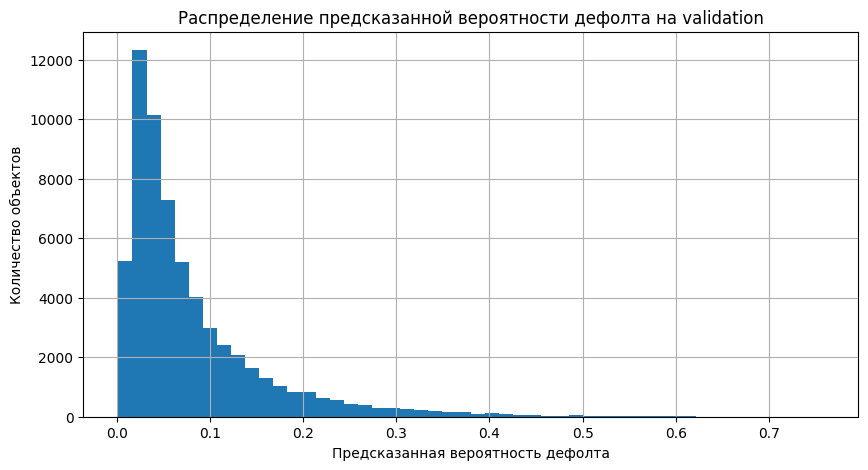

In [10]:
display(
    validation_scored["proba"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

plt.figure(figsize=(10, 5))
plt.hist(validation_scored["proba"], bins=50)
plt.title("Распределение предсказанной вероятности дефолта на validation")
plt.xlabel("Предсказанная вероятность дефолта")
plt.ylabel("Количество объектов")
plt.grid(True)
plt.show()

## бизнес-интерпретация


In [11]:
approved = validation_scored[validation_scored["approved_amount"] > 0].copy()
declined = validation_scored[validation_scored["approved_amount"] == 0].copy()

business_summary = pd.DataFrame(
    {
        "метрика": [
            "Доля одобренных",
            "Дефолтность среди одобренных",
            "Дефолтность среди отклонённых",
            "Объём невозврата",
            "Объём возвращённого основного долга",
            "Доход на возвращённом долге (5%)",
            "Итоговый доход",
        ],
        "значение": [
            len(approved) / len(validation_scored),
            approved["TARGET"].mean(),
            declined["TARGET"].mean(),
            approved.loc[approved["TARGET"] == 1, "approved_amount"].sum(),
            approved.loc[approved["TARGET"] == 0, "approved_amount"].sum(),
            approved.loc[approved["TARGET"] == 0, "approved_amount"].sum() * 0.05,
            validation_scored["realized_income"].sum(),
        ],
    }
)

business_summary

,метрика,значение
0,Доля одобренных,4.749362e-01
1,Дефолтность среди одобренных,2.766176e-02
2,Дефолтность среди отклонённых,1.287276e-01
3,Объём невозврата,1.254500e+08
4,Объём возвращённого основного долга,5.327500e+09
5,Доход на возвращённом долге (5%),2.663750e+08
6,Итоговый доход,1.409250e+08


In [12]:
validation_scored.groupby("decision", as_index=False).agg(
    rows=("decision", "size"),
    avg_proba=("proba", "mean"),
    avg_amount=("approved_amount", "mean"),
    total_realized_income=("realized_income", "sum"),
)

,decision,rows,avg_proba,avg_amount,total_realized_income
0,ACCEPTED,29210,0.028640,186680.931188,140925000.0
1,DECLINED,32293,0.127339,0.000000,0.0
